<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/06_modeling_workflow_with_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling with scikit-learn

In [1]:
# standard library imports
import functools
from pathlib import Path

# data tools
import polars as pl
import polars.selectors as cs
import geopandas
import numpy as np

# graphing tools
import altair as alt
import matplotlib.pyplot as plt

# sklearn config
from sklearn import set_config

# sklearn base types
from sklearn import tree
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# pipeline nodes
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer

# models
from sklearn.tree import DecisionTreeClassifier

# inspection and evaluation
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
alt.data_transformers.disable_max_rows()
np.set_printoptions(precision=2)
set_config(transform_output='polars')

## Loading Data

In [3]:
iris = load_iris(as_frame=True)
print(iris.frame.columns)
print(iris.target_names)
iris.frame.head()

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')
['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Finding "Good" Features

In [4]:
label_mapper = lambda label: iris.target_names[label]
df = (
    pl.from_pandas(iris.frame)
    .select(
        pl.col("sepal length (cm)").alias("sepalLength"),
        pl.col("sepal width (cm)").alias("sepalWidth"),
        pl.col("petal length (cm)").alias("petalLength"),
        pl.col("petal width (cm)").alias("petalWidth"),
        pl.col("target").map_elements(
            label_mapper,
            return_dtype=pl.String
            ).alias("species"),
    )
)

df.head()

sepalLength,sepalWidth,petalLength,petalWidth,species
f64,f64,f64,f64,str
5.1,3.5,1.4,0.2,"""setosa"""
4.9,3.0,1.4,0.2,"""setosa"""
4.7,3.2,1.3,0.2,"""setosa"""
4.6,3.1,1.5,0.2,"""setosa"""
5.0,3.6,1.4,0.2,"""setosa"""


### Feature Distribution

In [5]:
alt.Chart(df).transform_fold(
    [
        "petalWidth",
        "petalLength",
        "sepalWidth",
        "sepalLength",
    ],
    as_=["Measurement_type", "value"],
).transform_density(
    density="value",
    bandwidth=0.3,
    groupby=["Measurement_type"],
    extent=[0, 8],
).mark_area().encode(
    alt.X("value:Q"),
    alt.Y("density:Q"),
    alt.Row("Measurement_type:N"),
).properties(
    width=300, height=50
)

alt.Chart(...)

### Relating Features and Target

**Do features contain enough information to predict target label?**

In [6]:
chart1 = alt.Chart(df).mark_point().encode(
    x=alt.X('petalWidth').title("Petal Width"),
    y=alt.Y('petalLength').title("Petal Length"),
    color=alt.Color('species').title("Species")
).properties(
    height=300,
    width=300
)

chart2 = alt.Chart(df).mark_bar().encode(
    x=alt.X('count()'),
    y=alt.Y('petalWidth:Q').bin(maxbins=30).title("Petal Width (binned)"),
    color=alt.Color('species').title("Species")
).properties(
    height=300,
    width=100
)

chart1 | chart2

alt.HConcatChart(...)

In [7]:
alt.Chart(df).mark_point(opacity=0.5).encode(
    alt.X(alt.repeat("column"), type='quantitative'),
    alt.Y(alt.repeat("row"), type='quantitative'),
    color='species:N'
).properties(
    width=200,
    height=200
).repeat(
    row=['petalLength', 'petalWidth'],
    column=['sepalLength', 'sepalWidth']
)

alt.RepeatChart(...)

In [8]:
alt.Chart(df, width=500).transform_window(
    index='count()'
).transform_fold(
    ['petalLength', 'petalWidth', 'sepalLength', 'sepalWidth']
).mark_line().encode(
    x='key:N',
    y='value:Q',
    color='species:N',
    detail='index:N',
    opacity=alt.value(0.5)
)

alt.Chart(...)

## Modeling to Predict Iris Species

**Modeling Workflow**:

1. Load & Prepare Data
1. Split the data
1. Initialize Model
1. Train the Model
1. Predict Labels
1. Evaluate Model Performance

  **Key Concepts:**
  - [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
  - Overfitting
  - Decision Boundary
  - Confusion Matrix
  - [Precision Recall](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#)

Mo

In [9]:
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)

In [10]:
clf.score(X_test, y_test)

0.9736842105263158

In [11]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

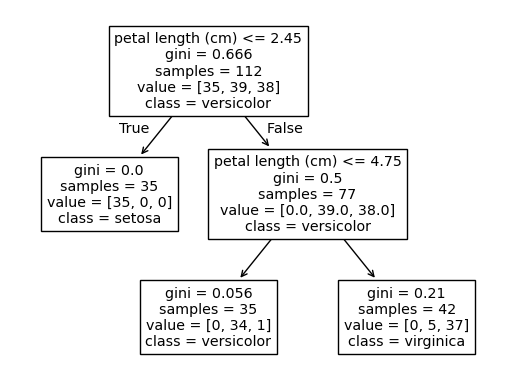

In [12]:
iris_tree = tree.plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names)
fig = plt.gcf()
fig.savefig("iris_tree.png")

Confusion matrix, without normalization
[[15  0  0]
 [ 0 10  1]
 [ 0  0 12]]
Normalized confusion matrix
[[1.   0.   0.  ]
 [0.   0.91 0.09]
 [0.   0.   1.  ]]


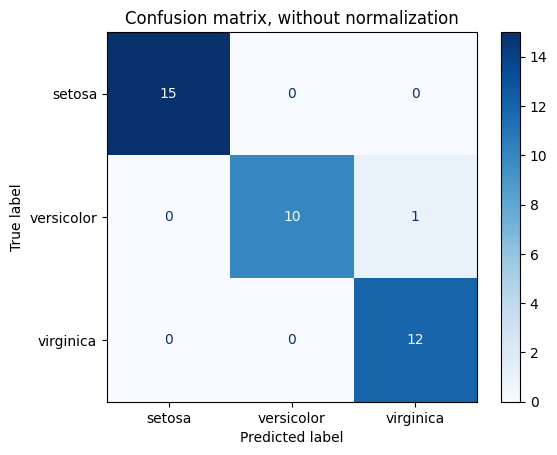

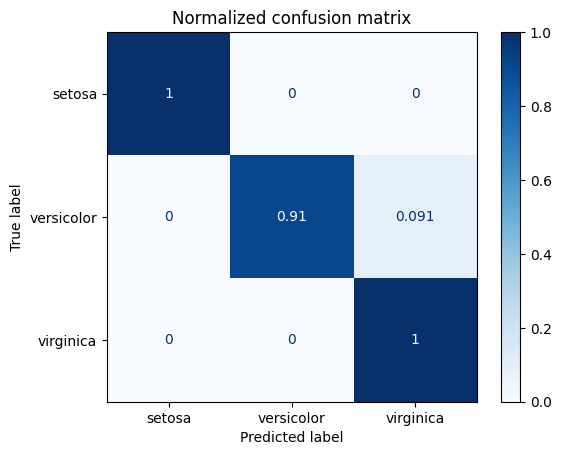

In [13]:
class_names = iris.target_names
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

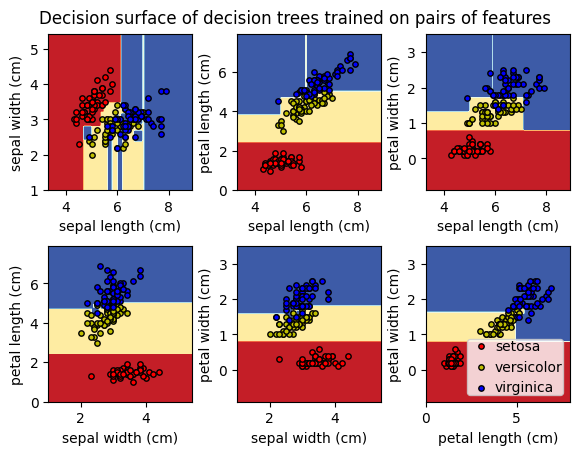

In [14]:
iris = load_iris()

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target
    class_names = iris.target_names

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.asarray(y == i).nonzero()
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")